# Dealer Gamma vs Realized Vol → a Risk-Managed Short-Vol Strategy
### A reproducible walkthrough — and an honest account of what survived an internal audit

This notebook ties together the two deliverables of the project:

1. **[`FINDINGS.md`](../FINDINGS.md)** — *is dealer gamma a VIX echo?* (mostly, with a small real increment)
2. **[`STRATEGY.md`](../STRATEGY.md)** — a risk-managed short-volatility **variance-risk-premium carry** strategy.

**The arc that matters.** v1 of this project reported a "+0.84 Sharpe" that turned out to be a *single lucky day*. It was diagnosed, abandoned (`legacy/`, `docs/v1-retrospective.md`), and replaced with a falsifiable signal question and an honestly-benchmarked strategy. A first draft of the *strategy* then over-claimed too — and a self-run multi-agent adversarial audit caught it. **What follows is what remained after that audit.** Charts re-render from committed, ToS-clean artifacts (public VIX/VIXY/SPY-derived only), so this notebook runs without any licensed data.

In [1]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display

REPO = Path.cwd()
while not (REPO / "STRATEGY.md").exists() and REPO != REPO.parent:
    REPO = REPO.parent

R = json.load(open(REPO / "analysis/strategy_results.json"))
curves = pd.read_csv(REPO / "analysis/strategy_curves.csv", parse_dates=["date"])
print("window", R["window"], "| n", R["n"], "trading days")

window ['2011-07-28', '2026-05-28'] | n 3730 trading days


## Part A — The signal question: is dealer gamma a VIX echo?

Options dealers hedge inventory: long gamma → vol *suppressed*; short gamma → vol *amplified*. The trap is asking "does gamma beat VIX at forecasting RV?" — VIX **is** the market's price of forward variance. The sharp question is whether gamma adds skill *incremental to* a VIX/HAR baseline.

**Result (15 years, multi-regime, out-of-sample, confound-checked):** dealer gamma is **~95% a VIX echo**. On a calm 21-month window it is a clean null; on deep history it carries a **small but statistically robust gamma-specific increment** (Diebold-Mariano on CRPS *p* = 0.001; it is gamma, not the DIX flow signal, and it survives a richer VIX baseline). Economically marginal — and, as Part B shows, it adds **nothing** to a trading overlay.

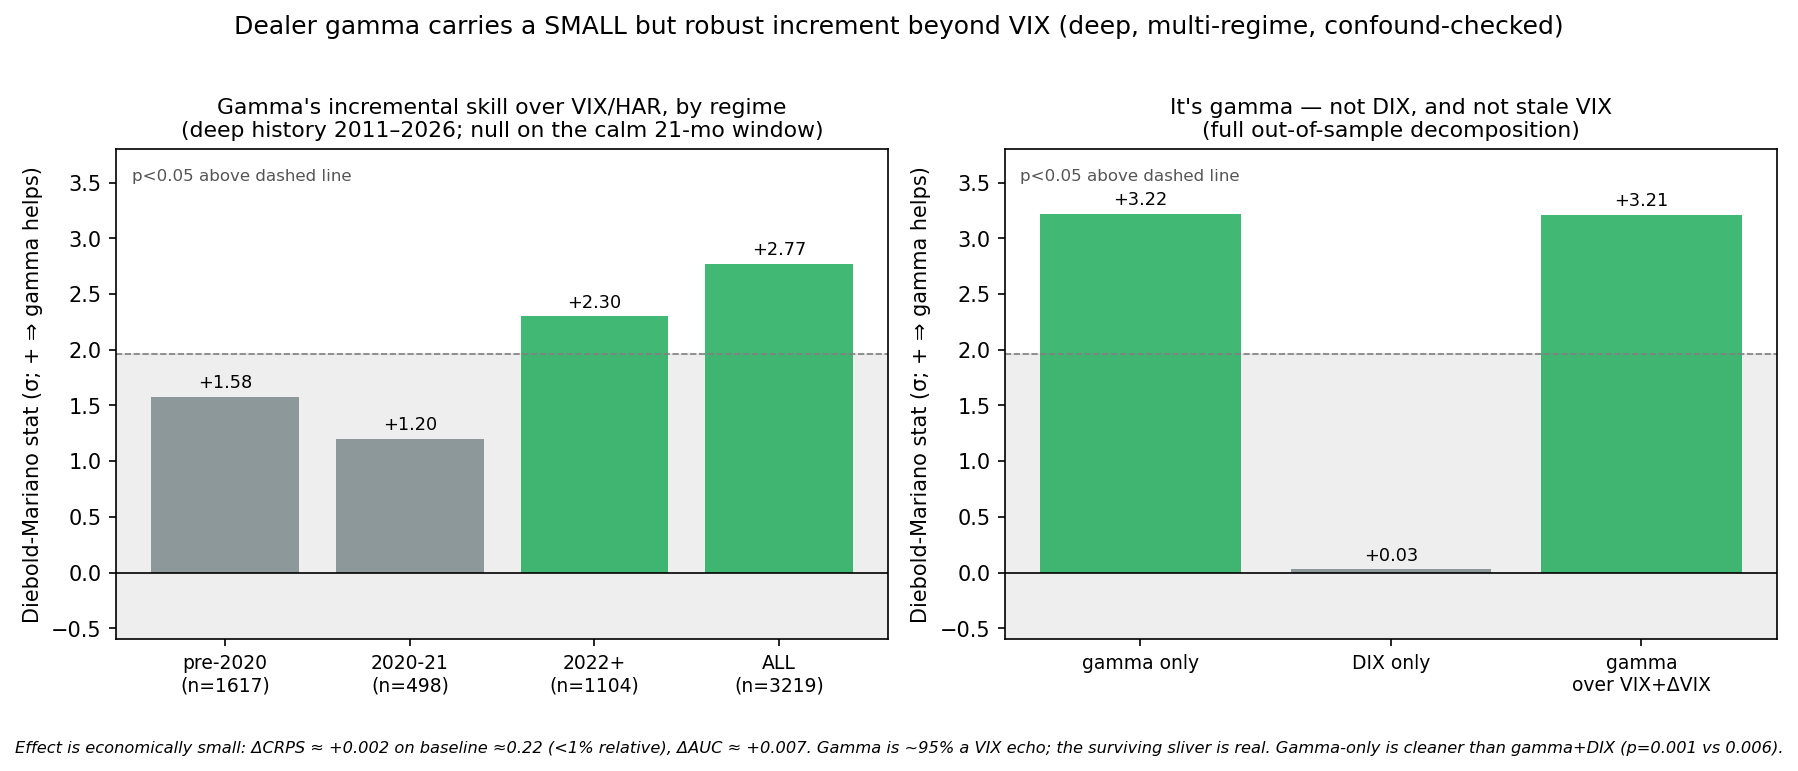

In [2]:
display(Image(filename=str(REPO / "analysis/figures/deep_history_result.png")))

## Part B — The strategy: short VIXY only in contango

**Rule (zero tuned parameters):** short a fixed, modest notional of VIXY whenever `VIX < VIX3M` (term structure in contango); flat otherwise. Signals from the prior close; P&L close-to-close; net of 10 bps turnover + a borrow fee. The headline table — note it is quoted *honestly* against SPY both excess-of-rf and total-return.

In [3]:
H = R["headline_metrics"]; B = R["benchmarks"]
tbl = pd.DataFrame({
    "Contango carry": [H["sharpe"], H["sortino"], H["calmar"], H["cagr"], H["ann_vol"], H["maxdd"]],
    "SPY (excess)":   [B["buy-hold SPY (excess)"]["sharpe"], B["buy-hold SPY (excess)"]["sortino"],
                       B["buy-hold SPY (excess)"]["calmar"], B["buy-hold SPY (excess)"]["cagr"],
                       None, B["buy-hold SPY (excess)"]["maxdd"]],
    "SPY (total ret)":[B["buy-hold SPY (total ret)"]["sharpe"], B["buy-hold SPY (total ret)"]["sortino"],
                       B["buy-hold SPY (total ret)"]["calmar"], B["buy-hold SPY (total ret)"]["cagr"],
                       None, B["buy-hold SPY (total ret)"]["maxdd"]],
}, index=["Sharpe", "Sortino", "Calmar", "CAGR", "Ann vol", "maxDD"]).round(3)
print(tbl.to_string())
print("\nHonest read: the carry TRAILS SPY on Sharpe and Sortino; it WINS on Calmar / maxDD.")

         Contango carry  SPY (excess)  SPY (total ret)
Sharpe            0.743         0.783            0.878
Sortino           0.807         0.961            1.074
Calmar            0.555         0.377            0.433
CAGR              0.085         0.127            0.146
Ann vol           0.119           NaN              NaN
maxDD            -0.153        -0.338           -0.337

Honest read: the carry TRAILS SPY on Sharpe and Sortino; it WINS on Calmar / maxDD.


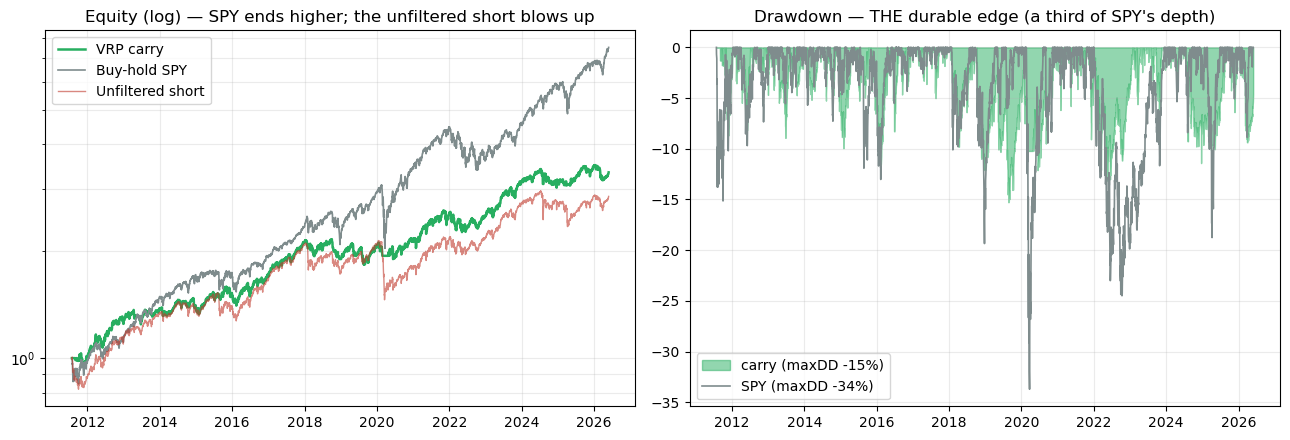

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(curves["date"], curves["carry"], color="#27ae60", lw=1.8, label="VRP carry")
a1.plot(curves["date"], curves["spy_total"], color="#7f8c8d", lw=1.2, label="Buy-hold SPY")
a1.plot(curves["date"], curves["constant"], color="#c0392b", lw=1.0, alpha=0.6, label="Unfiltered short")
a1.set_yscale("log"); a1.set_title("Equity (log) — SPY ends higher; the unfiltered short blows up"); a1.legend(); a1.grid(alpha=.25, which="both")
a2.fill_between(curves["date"], curves["carry_dd"]*100, 0, color="#27ae60", alpha=.5, label=f"carry (maxDD {H['maxdd']*100:.0f}%)")
a2.plot(curves["date"], curves["spy_dd"]*100, color="#7f8c8d", lw=1.2, label=f"SPY (maxDD {B['buy-hold SPY (total ret)']['maxdd']*100:.0f}%)")
a2.set_title("Drawdown — THE durable edge (a third of SPY's depth)"); a2.legend(loc="lower left"); a2.grid(alpha=.25)
plt.tight_layout(); plt.show()

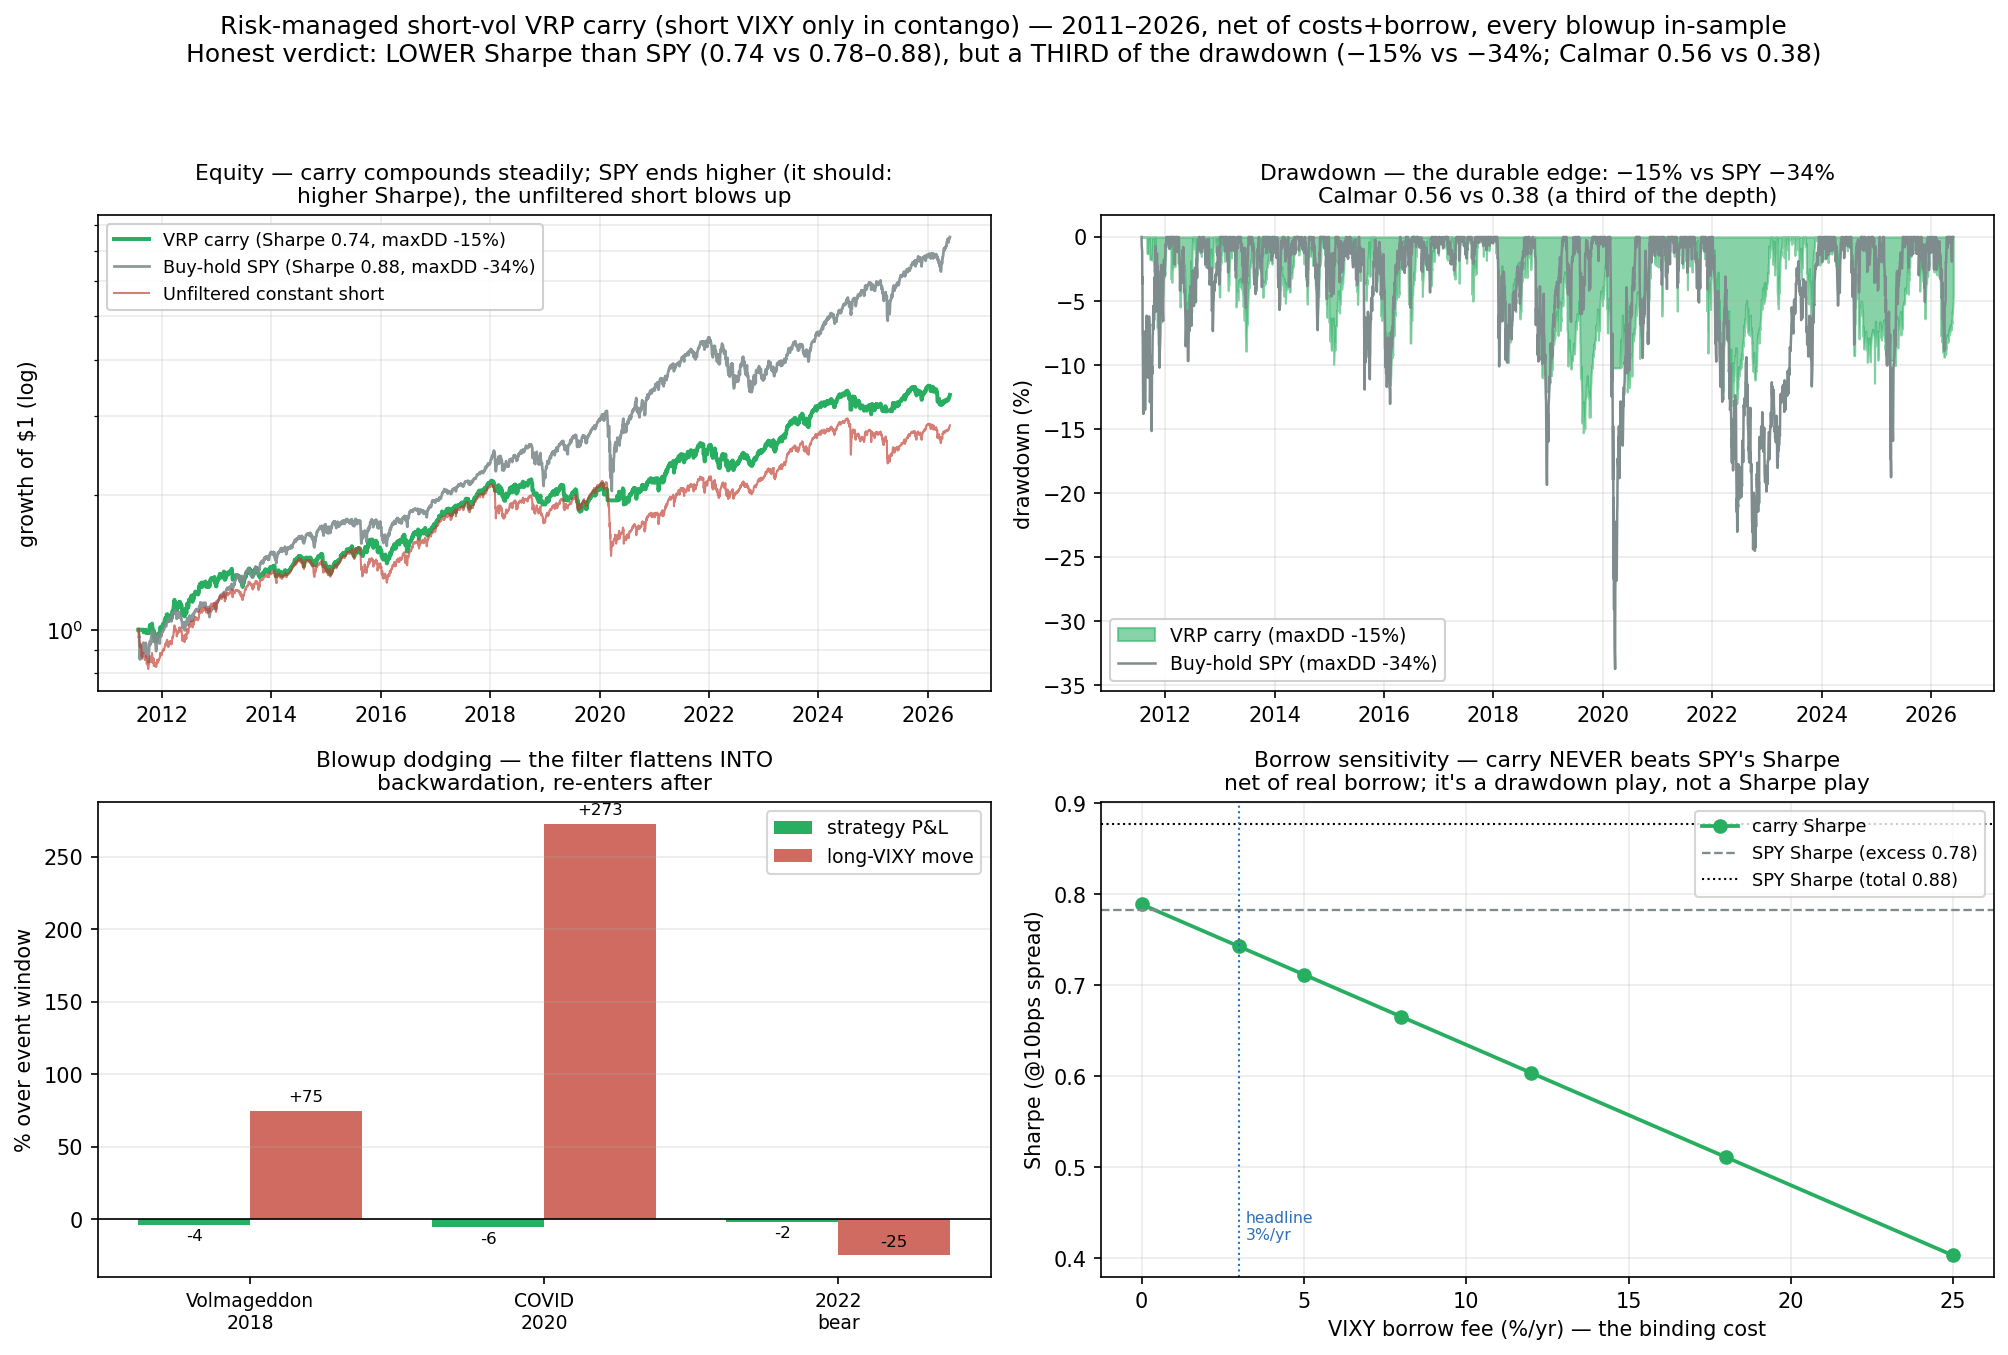

In [5]:
display(Image(filename=str(REPO / "analysis/figures/strategy_headline.png")))

## The honest verdict (what the audit corrected)

A first draft over-claimed. The internal adversarial audit (no look-ahead confirmed; math reproduced) forced these corrections — which are now the result:

- **No Sharpe edge over SPY.** The durable, convention-robust edge is **drawdown control** (Calmar/maxDD), not Sharpe.
- **Deflated Sharpe is a *range*, not 0.98.** The 0.98 was inflated by feeding the DSR correlated short-VIXY clones; the honest range below is much lower.
- **Per-regime: only pre-2020 is individually significant.** The COVID-era positive Sharpe is *not* distinguishable from zero. The edge roughly halves post-2018.

In [6]:
print(f"Deflated Sharpe range : {R['dsr']['range'][0]:.2f} – {R['dsr']['range'][1]:.2f}   (NOT the clone-inflated 0.98)")
print(f"Bootstrap P(SR<=0)    : {R['bootstrap_ci_vs0'][2]:.3f}  (vs ZERO, no multiplicity adjustment)")
print(f"Timing sleeve OOS AUC : {R['timing_auc']:.3f}  (a coin flip -> honest null)")
print(f"Carry-SPY correlation : {R['carry_spy_corr']:+.2f}  (equity-like premium, NOT uncorrelated alpha)\n")
print("Per-regime (HAC t-stat):")
for b, m in R["regime"].items():
    sig = "significant" if abs(m["t_hac"]) > 1.96 else "NOT significant"
    print(f"  {b:<9s} Sharpe {m['sharpe']:+.2f}  t_HAC {m['t_hac']:+.2f}  ({sig})")
print("\nOut-of-sample sub-periods (edge halves post-2018 but stays positive):")
for b, m in R["subperiods"].items():
    print(f"  {b:<18s} Sharpe {m['sharpe']:+.2f} (t {m['t_hac']:+.1f})  Calmar {m['calmar']:+.2f}")

Deflated Sharpe range : 0.66 – 0.81   (NOT the clone-inflated 0.98)
Bootstrap P(SR<=0)    : 0.001  (vs ZERO, no multiplicity adjustment)
Timing sleeve OOS AUC : 0.507  (a coin flip -> honest null)
Carry-SPY correlation : +0.61  (equity-like premium, NOT uncorrelated alpha)

Per-regime (HAC t-stat):
  pre2020   Sharpe +0.81  t_HAC +2.52  (significant)
  2020-21   Sharpe +0.83  t_HAC +1.42  (NOT significant)
  2022+     Sharpe +0.57  t_HAC +1.35  (NOT significant)

Out-of-sample sub-periods (edge halves post-2018 but stays positive):
  2011-2018          Sharpe +0.82 (t +2.4)  Calmar +0.75
  2019-2026          Sharpe +0.67 (t +2.1)  Calmar +0.60
  2018+ (post-XIV)   Sharpe +0.50 (t +1.6)  Calmar +0.37


## Where this goes next

A cited, OOS-screened extension roadmap is in **[`docs/strategy-extensions-research.md`](../docs/strategy-extensions-research.md)** — the three highest-value free-data upgrades all attack the *drawdown*, not the Sharpe: continuous roll-scaled sizing, forward-VRP conditioning (model-free IV − Yang-Zhang RV), and a convex left-tail floor. Dead-ends to drop (gamma/DIX timing, naive vol-targeting, rough-vol on daily data) are named explicitly.

**Reproduce:** `python analysis/strategy_two_sleeve.py` then `python analysis/make_figure_strategy.py` (needs the free-data fetchers). This notebook itself re-runs from the committed `strategy_results.json` + `strategy_curves.csv` alone.